In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from src.data.market_loader import MarketLoader

from src.curves.curve_snapshot import CurveSnapshot
from src.curves.bootstrap.bootstrap_engine import BootstrapCurveEngine
from src.curves.projection_curve import ProjectionCurve
from src.curves.zero_curve import ZeroCurve
from src.curves.survival_curve import SurvivalCurve
from src.curves.simulator.hull_white import HullWhiteSimulator

from src.instruments.instrument_builder import InstrumentBuilder

from src.trades.interest_rate_swap import InterestRateSwap

from src.pricing.swap_pricer import SwapPricer

from src.risk.exposure.stochastic_exposure_engine import MonteCarloExposureEngine

from src.xva.cva_engine import CVAEngine
from src.xva.dva_engine import DVAEngine
from src.xva.fva_engine import FVAEngine
from src.xva.colva_engine import ColVAEngine
from src.xva.mva_engine import MVAEngine
from src.xva.kva_engine import KVAEngine
from src.xva.xva_report import XVAReport

Times: 0 ---> Survival Probability: 1.0000
Times: 1 ---> Survival Probability: 0.9950
Times: 2 ---> Survival Probability: 0.9900
Times: 3 ---> Survival Probability: 0.9851
Times: 4 ---> Survival Probability: 0.9802
Times: 5 ---> Survival Probability: 0.9753
Times: 6 ---> Survival Probability: 0.9704
Times: 7 ---> Survival Probability: 0.9656
Times: 8 ---> Survival Probability: 0.9608
Times: 9 ---> Survival Probability: 0.9560
Times: 10 ---> Survival Probability: 0.9512


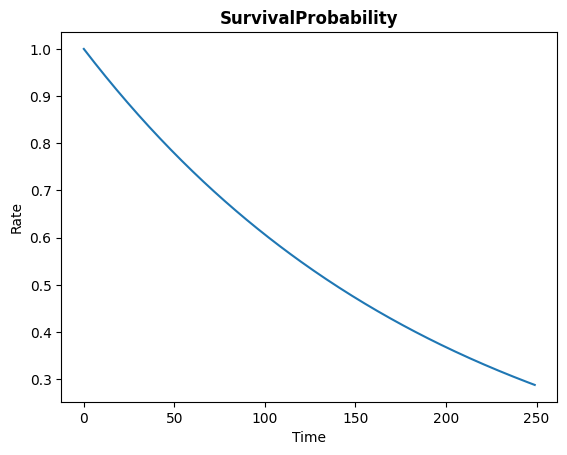

In [2]:
# survival curve
counterparty_survival_curve = SurvivalCurve(hazard_rate = 0.005)

times = list(range(250))

rows_survival = []

for t in times:
    if t <= 10: 
        print(f'Times: {t} ---> Survival Probability: {counterparty_survival_curve.survival_probability(t = t):.4f}')
    rows_survival.append({
        'Times': t, 
        'SurvivalProbability': counterparty_survival_curve.survival_probability(t = t)
    })

survival_df = pd.DataFrame(rows_survival)

plt.plot(survival_df['Times'], survival_df['SurvivalProbability'])
plt.title('SurvivalProbability', fontweight = 'bold')
plt.xlabel('Time')
plt.ylabel('Rate')
plt.show()


Times: 0 ---> Probability of Default: 0.0000
Times: 1 ---> Probability of Default: 0.0050
Times: 2 ---> Probability of Default: 0.0100
Times: 3 ---> Probability of Default: 0.0149
Times: 4 ---> Probability of Default: 0.0198
Times: 5 ---> Probability of Default: 0.0247
Times: 6 ---> Probability of Default: 0.0296
Times: 7 ---> Probability of Default: 0.0344
Times: 8 ---> Probability of Default: 0.0392
Times: 9 ---> Probability of Default: 0.0440
Times: 10 ---> Probability of Default: 0.0488


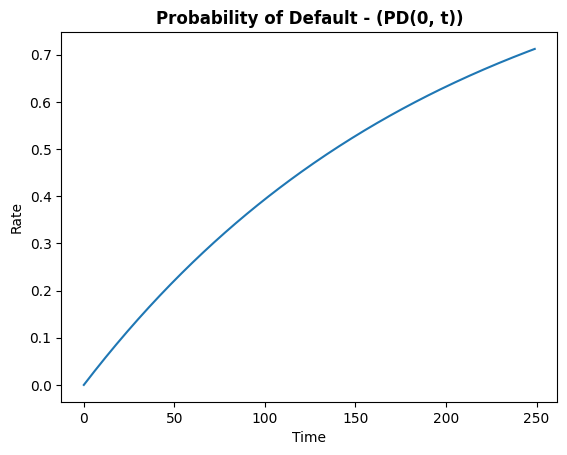

In [3]:
# probability of default - from initial point
rows_default = []

for t in times:
    if t <= 10:
        print(f'Times: {t} ---> Probability of Default: {counterparty_survival_curve.default_probability(start = times[0], end = t):.4f}')
    
    rows_default.append({
        'Times': t,
        'PD': counterparty_survival_curve.default_probability(start = times[0], end = t)
    })

default_df = pd.DataFrame(rows_default)
plt.plot(default_df['Times'], default_df['PD'])
plt.title('Probability of Default - (PD(0, t))', fontweight = 'bold')
plt.xlabel('Time')
plt.ylabel('Rate')
plt.show()

Times: 1 ---> Probability of Default: 0.0050
Times: 2 ---> Probability of Default: 0.0050
Times: 3 ---> Probability of Default: 0.0049
Times: 4 ---> Probability of Default: 0.0049
Times: 5 ---> Probability of Default: 0.0049
Times: 6 ---> Probability of Default: 0.0049
Times: 7 ---> Probability of Default: 0.0048
Times: 8 ---> Probability of Default: 0.0048
Times: 9 ---> Probability of Default: 0.0048
Times: 10 ---> Probability of Default: 0.0048


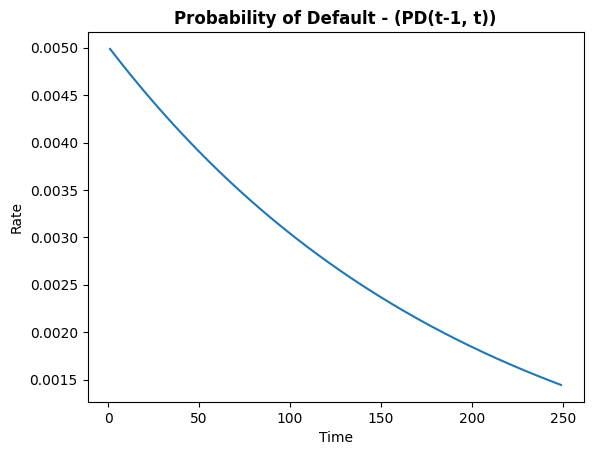

In [4]:
# probability of default - interval
rows_default = []

for t in times[1:]:
    if t <= 10:
        print(f'Times: {t} ---> Probability of Default: {counterparty_survival_curve.default_probability(start = t-1, end = t):.4f}')
    
    rows_default.append({
        'Times': t,
        'PD': counterparty_survival_curve.default_probability(start = t-1, end = t)
    })

default_df = pd.DataFrame(rows_default)
plt.plot(default_df['Times'], default_df['PD'])
plt.title('Probability of Default - (PD(t-1, t))', fontweight = 'bold')
plt.xlabel('Time')
plt.ylabel('Rate')
plt.show()

In [5]:
# downloading market curves
market_loader = MarketLoader()
market_curves = market_loader.market_loader_pipeline()

# downloading swap curves
swap_loader = MarketLoader()
swap_curves = swap_loader.swap_loader_pipeline()

treasury curve dataset already downloaded..
sofr curve dataset already downloaded..
futures curve dataset already downloaded..
estr curve dataset already downloaded..
usd_ois curve dataset already downloaded..
eur_ois curve dataset already downloaded..


In [6]:
### create curve snapshots
# SOFR snapshot
sofr_df = market_curves['sofr']

latest_date = sofr_df.index[-1]
latest_sofr_curve = sofr_df.iloc[-1]

sofr_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'sofr',
    as_of_date = latest_date,
    curve_row = latest_sofr_curve
)

# Futures snapshot
future_df = market_curves['futures']
latest_futures_curve = future_df.iloc[-1]

futures_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'futures',
    as_of_date = latest_date,
    curve_row = latest_futures_curve
)

# OIS snapshot
ois_df = swap_curves['usd_ois']

latest_swap_date = ois_df.index[-1]
latest_swap_curve = ois_df.iloc[-1]

ois_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'usd_ois',
    as_of_date = latest_swap_date,
    curve_row = latest_swap_curve
)

In [7]:
### create instruments from curve snapshot
# deposits
deposit_instruments = InstrumentBuilder.build_deposit_instruments(snapshot = sofr_snapshot)

# futures
future_instruments = InstrumentBuilder.build_future_instruments(snapshot = futures_snapshot)

# ois
ois_instruments = InstrumentBuilder.build_ois_instruments(snapshot = ois_snapshot)

### discount, projection and zero curve builder
# bootstrapping engine for generating the discount curve
all_instruments = deposit_instruments + future_instruments + ois_instruments

engine = BootstrapCurveEngine()

discount_curve = engine.bootstrap(
    snapshot = sofr_snapshot,
    instruments = all_instruments
)

# projection curve
projection_curve = ProjectionCurve(discount_curve = discount_curve)

# zero curve
zero_curve = ZeroCurve(discount_curve = discount_curve)

In [8]:
# sample IRS trade objects
IR_swap = InterestRateSwap(
    notional = 1_000_000,
    maturity = 3.0,
    fixed_rate = 3.40,
    pay_fixed = True
)

In [9]:
### exposure risk analytics
# pricer
pricer = SwapPricer(
    discount_curve = discount_curve,
    projection_curve = projection_curve
)

# simulator
simulator = HullWhiteSimulator(
    r0 = min(zero_curve.zero_rates.values()),
    random_seed = 12,
    mean_reversion = 0.1,
    volatility = 0.002
)

# exposure engine
mc_engine = MonteCarloExposureEngine(
    pricer = pricer,
    simulator = simulator,
    zero_curve = zero_curve
)

In [10]:
# CVA framework
cva_engine = CVAEngine(
    exposure_engine = mc_engine,
    discount_curve = discount_curve,
    survival_curve = counterparty_survival_curve,
    recovery_rate = 0.4
)

cva_profile, cva = cva_engine.cva_profile(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
) 

print(f'Total CVA: {cva:.1f}')

cva_profile

Total CVA: 28.2


,Times,EE,DF,PD,CVA_Contribution
0,0.00,7858.414276,0.999999,0.000000,0.000000
1,0.25,7490.225219,0.991079,0.001249,5.564075
2,0.50,7098.089779,0.982141,0.001248,5.218702
3,0.75,5718.773644,0.972673,0.001246,4.158858
4,1.00,4558.018079,0.963206,0.001245,3.278357
5,1.25,4082.127955,0.954487,0.001243,2.905863
6,1.50,3335.136975,0.945769,0.001241,2.349494
7,1.75,2489.983124,0.937051,0.001240,1.735770
8,2.00,1652.971341,0.928333,0.001238,1.140142
9,2.25,1298.426304,0.920364,0.001237,0.886797


In [11]:
# DVA framework
own_survival_curve = SurvivalCurve(hazard_rate = 0.01)

dva_engine = DVAEngine(
    exposure_engine = mc_engine,
    discount_curve = discount_curve,
    survival_curve = own_survival_curve,
    recovery_rate = 0.4
)

dva_profile, dva = dva_engine.dva_profile(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
)

print(f'Total DVA: {dva:.1f}')

dva_profile

Total DVA: 3.3


,Times,ENE,DF,PD,DVA_Contribution
0,0.00,-0.000000,0.999999,0.000000,-0.000000
1,0.25,-0.000000,0.991079,0.002497,-0.000000
2,0.50,24.376613,0.982141,0.002491,0.035778
3,0.75,84.633602,0.972673,0.002484,0.122712
4,1.00,179.598257,0.963206,0.002478,0.257225
5,1.25,201.544829,0.954487,0.002472,0.285330
6,1.50,289.259128,0.945769,0.002466,0.404755
7,1.75,331.594707,0.937051,0.002460,0.458569
8,2.00,488.628035,0.928333,0.002454,0.667775
9,2.25,395.334351,0.920364,0.002447,0.534302


In [12]:
# FVA framework
fva_engine = FVAEngine(
    exposure_engine = mc_engine,
    discount_curve = discount_curve,
    funding_spread = 0.005
)

fva_profile, fva = fva_engine.fva_profile(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
)

print(f'Total FVA: {fva:.1f}')

fva_profile

Total FVA: 48.2


,Times,EE,DF,dt,FVA_Contribution
0,0.00,7858.414276,0.999999,0.00,0.000000
1,0.25,7580.847292,0.991079,0.25,9.391522
2,0.50,7186.889987,0.982141,0.25,8.823177
3,0.75,5889.702129,0.972673,0.25,7.160946
4,1.00,4732.041542,0.963206,0.25,5.697411
5,1.25,4066.324155,0.954487,0.25,4.851569
6,1.50,3393.255010,0.945769,0.25,4.011545
7,1.75,2472.266758,0.937051,0.25,2.895800
8,2.00,1671.209730,0.928333,0.25,1.939298
9,2.25,1400.746643,0.920364,0.25,1.611496


In [13]:
# ColVA framework
funding_rate = 0.050
collateral_rate = 0.045

colva_engine = ColVAEngine(
    exposure_engine = mc_engine,
    discount_curve = discount_curve,
    funding_rate = funding_rate,
    collateral_rate = collateral_rate
)

colva_profile, colva = colva_engine.colva_profile(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
)

print(f'Total ColVA: {colva:.1f}')

colva_profile

Total ColVA: 47.3


,Times,EE,DF,dt,ColVA_Contribution
0,0.00,7858.414276,0.999999,0.00,0.000000
1,0.25,7459.356990,0.991079,0.25,9.241014
2,0.50,6953.034385,0.982141,0.25,8.536078
3,0.75,5729.700330,0.972673,0.25,6.966409
4,1.00,4618.026688,0.963206,0.25,5.560136
5,1.25,4017.703263,0.954487,0.25,4.793559
6,1.50,3342.323898,0.945769,0.25,3.951333
7,1.75,2480.026662,0.937051,0.25,2.904889
8,2.00,1702.283734,0.928333,0.25,1.975357
9,2.25,1407.473196,0.920364,0.25,1.619235


In [14]:
# MVA framework
funding_spread = funding_rate - collateral_rate
initial_margin_multiplier = 1.1
percentile = 95.0

mva_engine = MVAEngine(
    exposure_engine = mc_engine,
    discount_curve = discount_curve,
    funding_spread = funding_spread,
    im_multiplier = initial_margin_multiplier,
    percentile = percentile
)

mva_profile, mva = mva_engine.mva_profile(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
)

print(f'Total MVA: {mva:.1f}')

mva_profile

Total MVA: 112.1


,Times,InitialMargin,DF,dt,MVA_Contribution
0,0.00,8644.255703,0.999999,0.00,0.000000
1,0.25,13053.011820,0.991079,0.25,16.170705
2,0.50,13598.881115,0.982141,0.25,16.695030
3,0.75,13244.966154,0.972673,0.25,16.103784
4,1.00,11261.211200,0.963206,0.25,13.558576
5,1.25,9684.241358,0.954487,0.25,11.554357
6,1.50,9339.573682,0.945769,0.25,11.041351
7,1.75,7853.197575,0.937051,0.25,9.198558
8,2.00,5952.513754,0.928333,0.25,6.907392
9,2.25,4684.280574,0.920364,0.25,5.389056


In [15]:
# KVA framework
required_capital = 0.08
cost_of_capital = 0.10

kva_engine = KVAEngine(
    exposure_engine = mc_engine,
    discount_curve = discount_curve,
    capital_ratio = required_capital,
    cost_of_capital = cost_of_capital
)

kva_profile, kva = kva_engine.kva_profile(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4  
)

print(f'Total KVA: {kva:.1f}')

kva_profile

Total KVA: 76.6


,Times,EE,Capital,DF,dt,KVA_Contribution
0,0.00,7858.414276,628.673142,0.999999,0.00,0.000000
1,0.25,7169.997881,573.599830,0.991079,0.25,14.212067
2,0.50,6971.210582,557.696847,0.982141,0.25,13.693429
3,0.75,5815.214710,465.217177,0.972673,0.25,11.312610
4,1.00,4737.066425,378.965314,0.963206,0.25,9.125537
5,1.25,4193.814837,335.505187,0.954487,0.25,8.005886
6,1.50,3398.175743,271.854059,0.945769,0.25,6.427779
7,1.75,2621.744181,209.739534,0.937051,0.25,4.913416
8,2.00,1871.240811,149.699265,0.928333,0.25,3.474268
9,2.25,1411.486183,112.918895,0.920364,0.25,2.598163


In [16]:
# XVA reports
xva_engine = XVAReport(
    cva_engine = cva_engine,
    dva_engine = dva_engine,
    fva_engine = fva_engine,
    colva_engine = colva_engine,
    mva_engine = mva_engine,
    kva_engine = kva_engine
)

summary_report_xva = xva_engine.summary_report(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
)

full_report_xva = xva_engine.full_report(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
)

display(summary_report_xva)
display(full_report_xva)

,Metrics,Value
0,CVA,28.727079
1,DVA,3.122189
2,BVA,-25.604889
3,FVA,44.851055
4,ColVA,44.139543
5,MVA,107.702419
6,KVA,73.706037
7,XVA,-296.003943


,Times,CVA_Contribution,DVA_Contribution,FVA_Contribution,ColVA_Contribution,MVA_Contribution,KVA_Contribution,BVA_Contribution,XVA_Contribution
0,0.00,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000
1,0.25,5.241385,0.001212,8.932687,9.010020,16.446057,14.213573,-5.240173,-53.842510
2,0.50,4.764876,0.026779,8.443304,8.421155,17.508005,13.468574,-4.738097,-52.579135
3,0.75,3.919194,0.179461,6.707669,6.812790,14.802781,11.542697,-3.739733,-43.605670
4,1.00,3.098911,0.438412,5.509111,5.397619,14.162440,8.974927,-2.660499,-36.704595
5,1.25,2.626317,0.624693,4.531935,4.657165,12.916013,7.441586,-2.001624,-31.548323
6,1.50,2.239993,0.649804,3.627470,3.838801,11.236643,6.456578,-1.590189,-26.749681
7,1.75,1.709178,0.753532,2.908163,2.967915,8.950788,5.002683,-0.955646,-20.785195
8,2.00,1.130965,0.759649,2.000818,2.101740,6.983076,3.391760,-0.371316,-14.848710
9,2.25,0.884113,0.600266,1.604841,1.673825,5.363751,2.699692,-0.283846,-11.625955
